In [ ]:
import os 

import numpy as np
import pandas as pd

from scipy.ndimage import gaussian_filter1d

import networkx as nx
import igraph as ig 
import leidenalg as la

import graph_tool.all as gt

import matplotlib.pyplot as plt
# import clolorsys

### Reading in the Data

In [2]:
df_all = pd.read_csv("data/coelution/repl1_repl2_combined.tsv", sep='\t', index_col=0)

In [106]:
# reading in the one cluster of proteins: 
df_oneclust = pd.read_csv("data/coelution/onecluster.csv", index_col=0)
prot_list = list(df_oneclust['xxx'].unique())
len(prot_list)

2341

### Separating the replicates + Filtering bad proteins

In [139]:
# Separate the replicates
replicate_1 = [c for c in df_all.columns if 'repl1' in c]
replicate_2 = [c for c in df_all.columns if 'repl2' in c]
df_repl1 = df_all[replicate_1]
df_repl2 = df_all[replicate_2]

# Downsampling to the one_cluster size
df_repl1 = df_repl1.loc[prot_list]
df_repl2 = df_repl2.loc[prot_list]



# Getting the proteins with all NaN values in either replicates
all_null_prots_1 = df_repl1[df_repl1.isnull().all(axis=1)].index
all_null_prots_2 = df_repl2[df_repl2.isnull().all(axis=1)].index
all_null_both = all_null_prots_1.intersection(all_null_prots_2)
print("%i proteins have all NaN values in Repl1; %i proteins have all NaN values in Repl2 " % (len(all_null_prots_1), len(all_null_prots_2)))
print("%i proteins have all NaN values in both Repl1 and Repl2; these will be dropped" % (len(all_null_both)))

df_repl1 = df_repl1.drop(all_null_both)
df_repl2 = df_repl2.drop(all_null_both)

print("Final Shape of repl1 is: (%i, %i)" % df_repl1.shape)
print("Final Shape of repl2 is: (%i, %i)" % df_repl2.shape)

39 proteins have all NaN values in Repl1; 82 proteins have all NaN values in Repl2 
1 proteins have all NaN values in both Repl1 and Repl2; these will be dropped
Final Shape of repl1 is: (2340, 72)
Final Shape of repl2 is: (2340, 72)


In [140]:
def get_color_palette(n_colors):
    """
    Generate a color palette with the specified number of distinct colors.
    
    Args:
        n_colors (int): Number of colors to generate
        
    Returns:
        list: List of RGB tuples
    """
    
    # Use 'viridis' as base colormap - it's perceptually uniform and colorblind-friendly
    cmap = plt.cm.tab10
    
    # Generate evenly spaced colors
    colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]
    
    return colors

# Example usage:
color_palette = get_color_palette(10)  # generates 10 distinct colors

In [141]:
protein_samples = df_repl1.sample(10).index

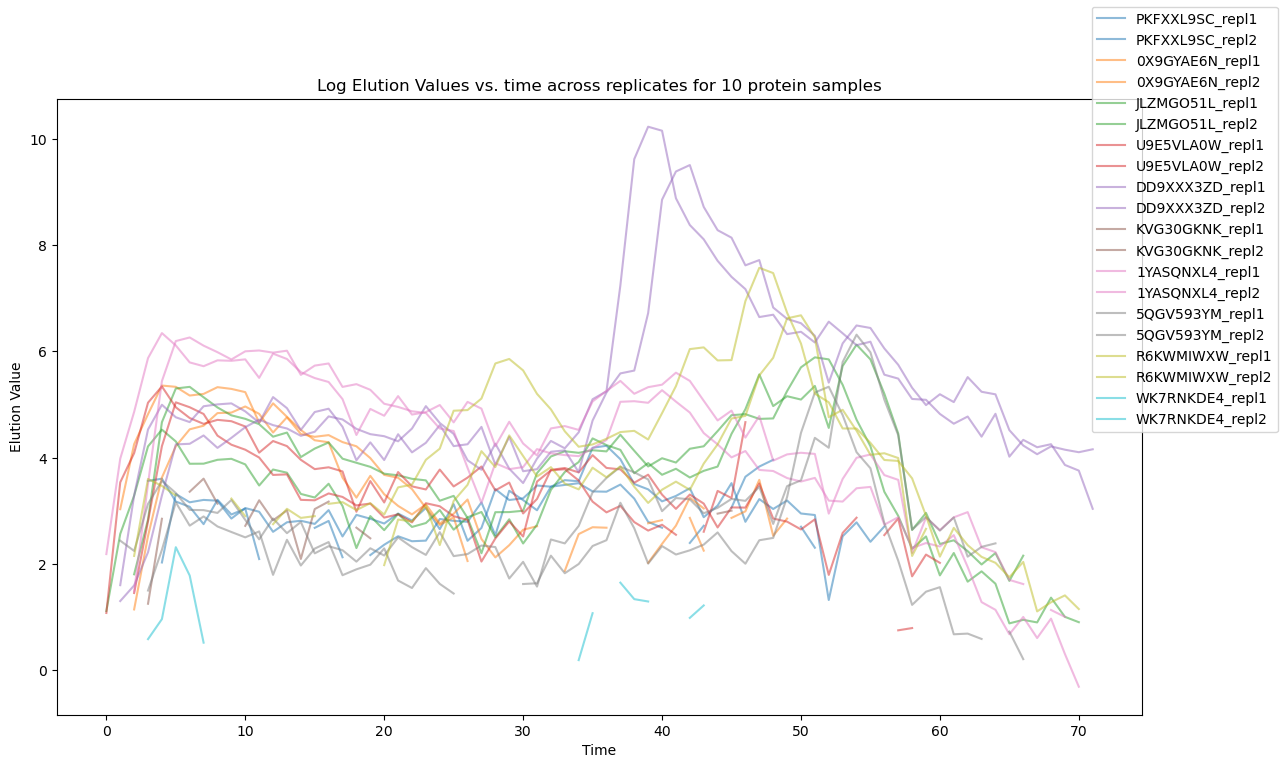

In [142]:
fig, ax = plt.subplots(figsize=(14, 8))

for i, prot in enumerate(protein_samples): 
    prot_vals_rep1 = df_repl1.loc[prot] #.fillna(0.01)
    prot_vals_rep2 = df_repl2.loc[prot] #.fillna(0.01)

    ax.plot(np.log(prot_vals_rep1.values), c=color_palette[i], alpha=0.5, label=f"{prot}_repl1")
    ax.plot(np.log(prot_vals_rep2.values), c=color_palette[i], alpha=0.5, label=f"{prot}_repl2")

ax.set_title("Log Elution Values vs. time across replicates for 10 protein samples")
ax.set_xlabel("Time")
ax.set_ylabel("Elution Value")

fig.legend(loc='upper right', )
plt.show()


### Applying a Gaussian Filter


In [143]:
_sigma=1
_mode = 'mirror'
_radius = 1
df_repl1_filt = pd.DataFrame(gaussian_filter1d(df_repl1, sigma=_sigma, mode=_mode, radius=_radius, axis=1), index=df_repl1.index, columns=df_repl1.columns)
df_repl2_filt = pd.DataFrame(gaussian_filter1d(df_repl2, sigma=_sigma, mode=_mode, radius=_radius, axis=1), index=df_repl2.index, columns=df_repl2.columns)

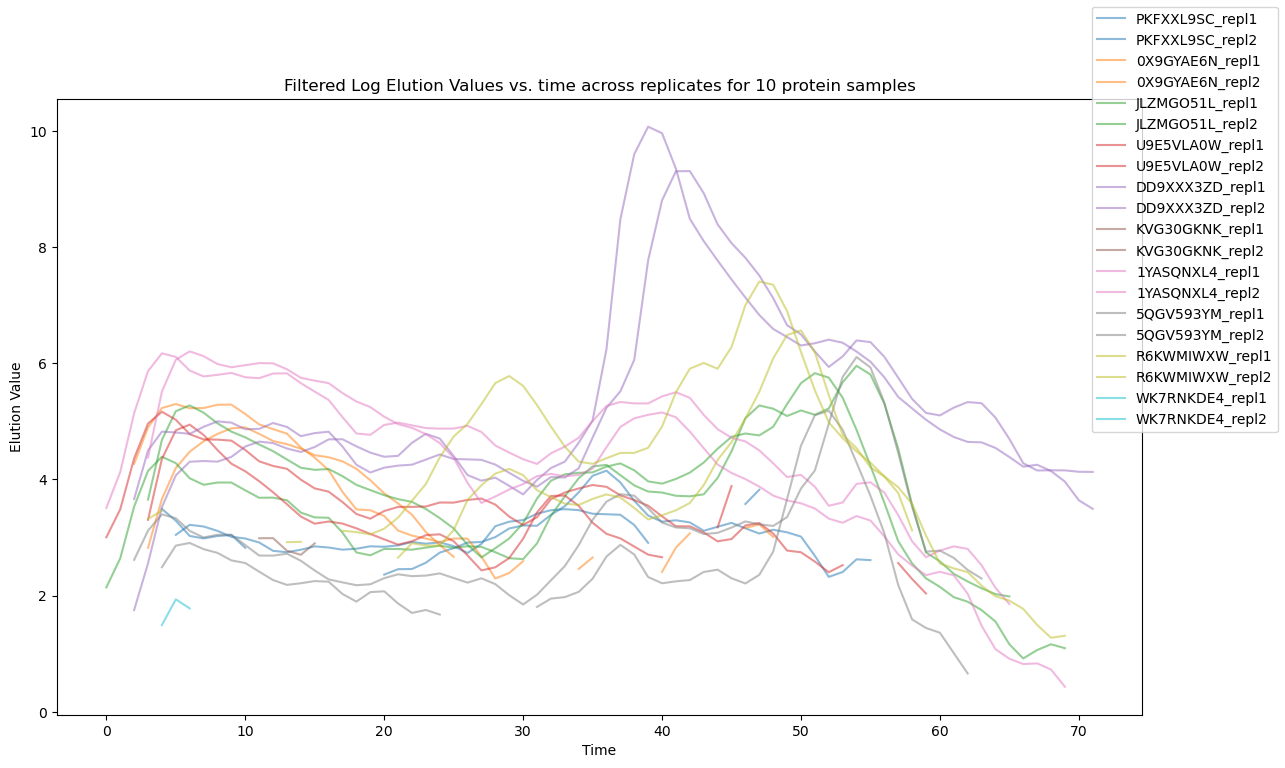

In [144]:
fig, ax = plt.subplots(figsize=(14, 8))

for i, prot in enumerate(protein_samples): 
    prot_vals_rep1 = df_repl1_filt.loc[prot] #.fillna(0.01)
    prot_vals_rep2 = df_repl2_filt.loc[prot] #.fillna(0.01)

    ax.plot(np.log(prot_vals_rep1.values), c=color_palette[i], alpha=0.5, label=f"{prot}_repl1")
    ax.plot(np.log(prot_vals_rep2.values), c=color_palette[i], alpha=0.5, label=f"{prot}_repl2")

ax.set_title("Filtered Log Elution Values vs. time across replicates for 10 protein samples")
ax.set_xlabel("Time")
ax.set_ylabel("Elution Value")

fig.legend(loc='upper right', )
plt.show()


### Filtering NaNs post filter

In [152]:
all_null_prots_1 = df_repl1_filt[df_repl1_filt.isnull().all(axis=1)].index
all_null_prots_2 = df_repl2_filt[df_repl2_filt.isnull().all(axis=1)].index
all_null_both = all_null_prots_1.intersection(all_null_prots_2)
print("%i proteins have all NaN values in Repl1; %i proteins have all NaN values in Repl2 " % (len(all_null_prots_1), len(all_null_prots_2)))
print("%i proteins have all NaN values in both Repl1 and Repl2; these will be dropped" % (len(all_null_both)))
print("The proteins are")
[print(a) for a in all_null_both]

df_repl1_filt = df_repl1_filt.drop(all_null_both)
df_repl2_filt = df_repl2_filt.drop(all_null_both)
# print("The Other proteins will be filled in with 0 post correlations")


45 proteins have all NaN values in Repl1; 87 proteins have all NaN values in Repl2 
6 proteins have all NaN values in both Repl1 and Repl2; these will be dropped
The proteins are
VQ5YZ22KI
9FJGMYVXT
PA28L0DFW
1DVE54U76
BT6TPGGEO
UQDM9W5RX


### Using Pearson Correlations to build graph

In [ ]:
def create_graph_from_adjacency(adj_matrix, threshold=0.0):
    """
    Create a graph-tool Graph from a pandas adjacency matrix.
    
    Args:
        adj_matrix (pd.DataFrame): Adjacency matrix with protein names as index/columns
        threshold (float): Minimum correlation value to create an edge (default: 0.0)
        
    Returns:
        graph_tool.Graph: Created graph with edge weights
    """
    
    # Create a new undirected graph
    G = gt.Graph(directed=False)
    
    # Add vertex properties to store protein names
    v_name = G.new_vertex_property("string")
    
    # Create edge property for weights
    e_weight = G.new_edge_property("double")
    
    # Create vertices and store mapping
    vertex_dict = {}
    for protein in adj_matrix.index:
        v = G.add_vertex()
        vertex_dict[protein] = v
        v_name[v] = protein
    
    # Add edges where correlation exceeds threshold
    for i, protein1 in enumerate(adj_matrix.index):
        for j, protein2 in enumerate(adj_matrix.columns):
            if i < j:  # Only process upper triangle to avoid duplicates
                weight = adj_matrix.loc[protein1, protein2]
                if abs(weight) >= threshold:
                    e = G.add_edge(vertex_dict[protein1], vertex_dict[protein2])
                    e_weight[e] = weight
    
    # Add properties to graph
    G.vertex_properties["name"] = v_name
    G.edge_properties["weight"] = e_weight
    
    return G

# G = create_graph_from_adjacency(correlation_matrix, threshold=0.5)

In [159]:
df_repl1_corr = df_repl1_filt.T.corr().fillna(0)
np.fill_diagonal(df_repl1_corr.values, 0)
df_repl2_corr = df_repl2_filt.T.corr().fillna(0)
np.fill_diagonal(df_repl2_corr.values, 0)

In [178]:
# Plotting degree distributions of the correaltion matrices
def plot_corr_dist(vals, title="Corr Distribution", figsize=(8, 6)): 
    if type(vals) == list: 
        fig, ax = plt.subplots(1, len(vals), figsize=figsize)
        for i, v in enumerate(vals): 
            ax[i].hist(v, bins=20, alpha=0.8)
            ax[i].set_title(title[i])
    else: 
        fig, ax = plt.subplots(figsize=figsize)

        ax.hist(vals, bins=20, alpha=0.8)
        ax.set_title(title)
    return fig, ax

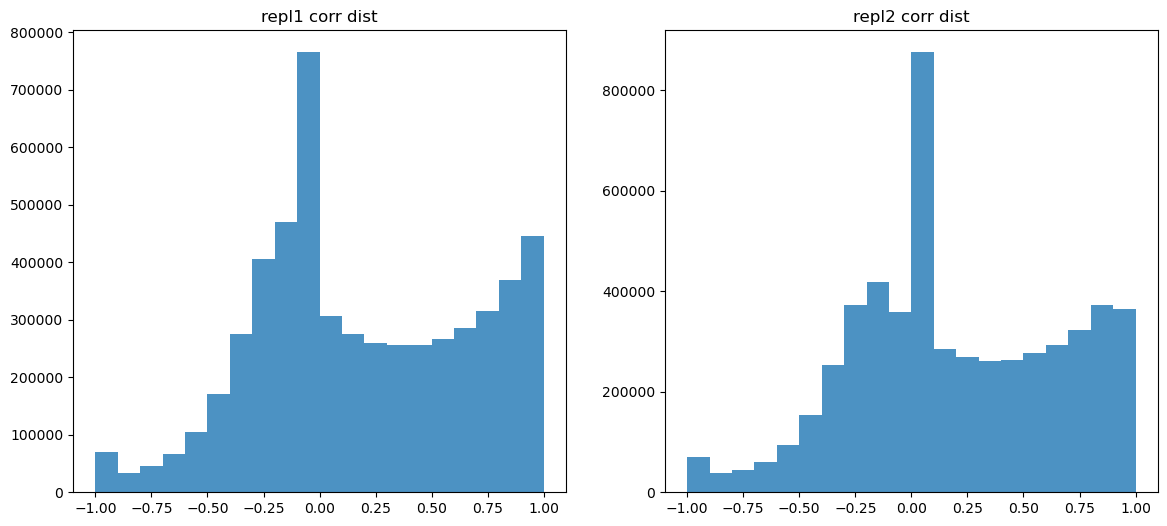

In [179]:
fig, ax = plot_corr_dist([df_repl1_corr.values.flatten(), df_repl2_corr.values.flatten()], figsize=(14, 6),
                        title = ['repl1 corr dist', 'repl2 corr dist'])
plt.show(fig)

In [189]:
# Parameters for filtering correlation matrix into graph
# _zscore_filt = 3 # number of zscores
_threshold  = 0.75 # manually decide based on the graphs above

G_repl1 = create_graph_from_adjacency(df_repl1_corr, threshold=_threshold)
G_repl2 = create_graph_from_adjacency(df_repl2_corr, threshold=_threshold)

In [196]:
thr_list = np.arange(0.5, 1, 0.05)
sim_list = []
for _thr in thr_list:
    G_repl1 = create_graph_from_adjacency(df_repl1_corr, threshold=_thr)
    G_repl2 = create_graph_from_adjacency(df_repl2_corr, threshold=_thr)
    g_sim = gt.similarity(G_repl1, G_repl2, eweight1=G_repl1.ep['weight'], eweight2=G_repl2.ep['weight']) #,  label1=G_repl1.vp['name'], label2=G_repl2.vp['name'])
    sim_list.append(g_sim)

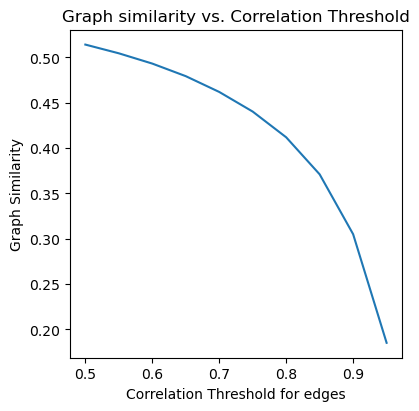

In [197]:
fig, ax = plt.subplots(figsize=(4, 4), constrained_layout=True)
ax.plot(thr_list, sim_list)
ax.set_title("Graph similarity vs. Correlation Threshold")
ax.set_xlabel("Correlation Threshold for edges")
ax.set_ylabel("Graph Similarity")
plt.show(fig)

In [191]:
G_repl1.vp['name']

<VertexPropertyMap object with value type 'string', for Graph 0x7f3e16cb1e50, at 0x7f3e16041fd0>

In [193]:
g_sim = gt.similarity(G_repl1, G_repl2, eweight1=G_repl1.ep['weight'], eweight2=G_repl2.ep['weight']) #,  label1=G_repl1.vp['name'], label2=G_repl2.vp['name'])

In [194]:
g_sim

0.4402899712396096

In [184]:
pos = gt.sfdp_layout(G, eweight=G.ep['weight'])
G.vp['pos'] = pos